In [319]:
import cv2
from utils import *
from plots import draw_homography,draw_matches
from homography import *
from fmatrix import *
import time
import numpy as np
import scipy 
import matplotlib.pyplot as plt

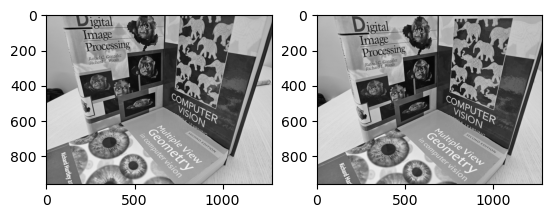

In [ ]:
img1 = cv2.imread('../Lab3/images/books1.jpg', flags=0)
img2 = cv2.imread('../Lab3/images/books2.jpg', flags=0)

plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')

## Recovering homographies

In [47]:
pts1, pts2 = extract_and_match_SIFT(img1, img2, num=100)    # top 100 matches

print(pts1.shape)    # array containing the keypoints from img1.
print(pts2.shape)    # array containing the keypoints from img2.

(2, 100)
(2, 100)


In [49]:
print(img1.shape)
print(img2.shape)

(960, 1280)
(960, 1280)


In [51]:
pts1, pts2 = extract_and_match_SIFT(img1, img2, num=100)    # top 100 matches

# convert to homogenous coordinates
pts1_h = np.vstack([pts1, np.ones(pts1.shape[1])])  # 3 x N
pts2_h = np.vstack([pts2, np.ones(pts2.shape[1])])  # 3 x N

N = pts1.shape[1]     # shape is (2, N)
A = []

for i in range(N):
    x, y = pts1[:, i]
    xb, yb = pts2[:, i]    # x', y' in the other image
    A.append([x, y, 1, 0, 0, 0, -x*xb, -y*xb, -xb])
    A.append([0, 0, 0, x, y, 1, -x*yb, -y*yb, -yb])

A = np.array(A)  # shape: 2N x 9

In [52]:
print(A.shape)

(200, 9)


In [53]:
C = np.transpose(A) @ A
print(C.shape)

(9, 9)


In [54]:
U, S, Vh = np.linalg.svd(C)
v = Vh[8,:]   # the eigenvector corresponding to the eigenvalue of C closest to zero

print(v.shape)

(9,)


In [55]:
H = v.reshape(3, 3)
print(H)

[[ 1.19384963e-02 -8.93426782e-05  7.26581259e-01]
 [-6.00304301e-04  1.22263116e-02  6.86739920e-01]
 [-8.83190763e-07 -5.79041374e-07  1.32505458e-02]]


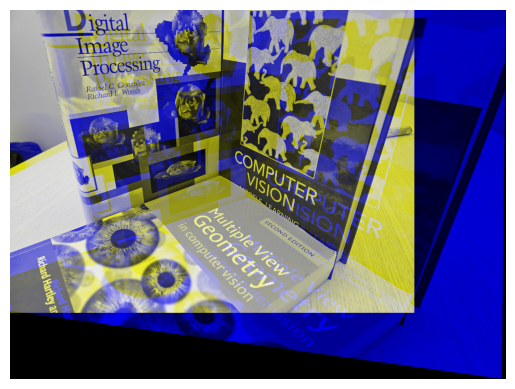

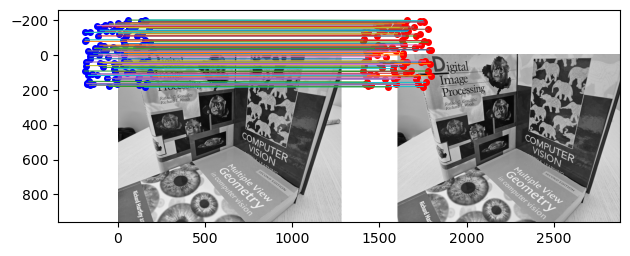

In [ ]:
pts1, pts2, H = generate_2d_points(num=100, noutliers=0, noise = 0.5, vergence = 10.0, focal = 1200)
H = find_homography(pts1, pts2)

# warps image 2 into the coordinate system of image 1 according to the homography H
# blue is image 2 (warped by H) and yellow is image 1
draw_homography(img1, img2, H, save = False) 

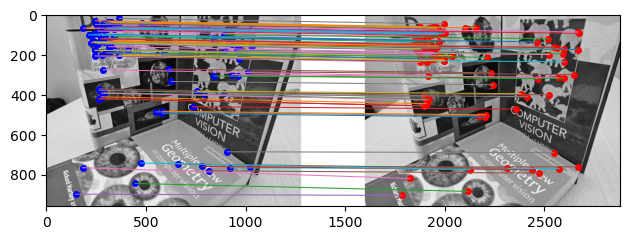

In [46]:
pts1, pts2 = extract_and_match_SIFT(img1, img2, num=100)
draw_matches(pts1, pts2, img1 = img1, img2 = img2)

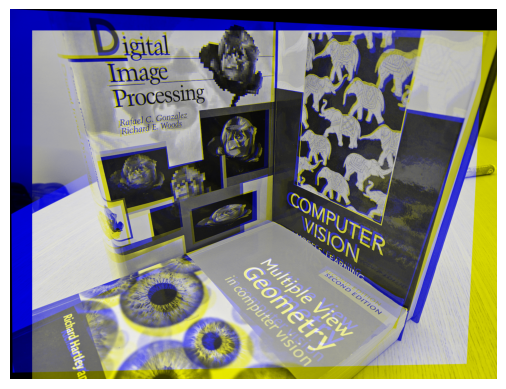

In [60]:
H = find_homography(pts1, pts2)

draw_homography(img1, img2, H, save = False)

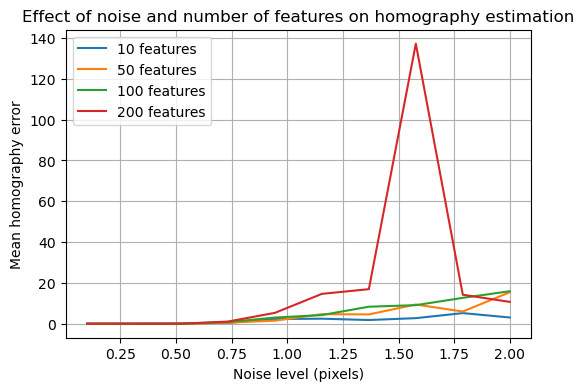

In [ ]:
noise_levels = np.linspace(0.1, 2, 10)
num_features = [10, 50, 100, 200]
repeats = 500
focal=1000

all_errors = {}

for num in num_features:
    mean_errors = []
    for noise in noise_levels:
        errors = []
        for _ in range(repeats):   # to get some average result since it changes every time
            # Generate synthetic points
            pts1, pts2, H_true = generate_2d_points(    # assumes that we have the camera matrix
                num=num,
                noutliers=0,
                noise=noise,
                vergence=10.0,
                focal=focal
            )
            
            # estimated homography
            H_est = find_homography(pts1, pts2)
            err = homography_error(H_est, H_true, focal=focal)
            errors.append(err)
            
        mean_errors.append(np.mean(errors))
    
    all_errors[num] = mean_errors


plt.figure(figsize=(6, 4))
for num, errors in all_errors.items():
    plt.plot(noise_levels, errors, label=f'{num} features')

plt.xlabel("Noise level (pixels)")
plt.ylabel("Mean homography error")
plt.title("Effect of noise and number of features on homography estimation")
plt.grid(True)
plt.legend()
plt.show()

At higher noise levels, the expected homography values are spread far away from the expected, true, homography values. At noise level of above 0.75, the error increases for 100 and 200 generated points. It seems that the more generated feature points we have, it becomes harder to represent the true homography in the presence of noise.

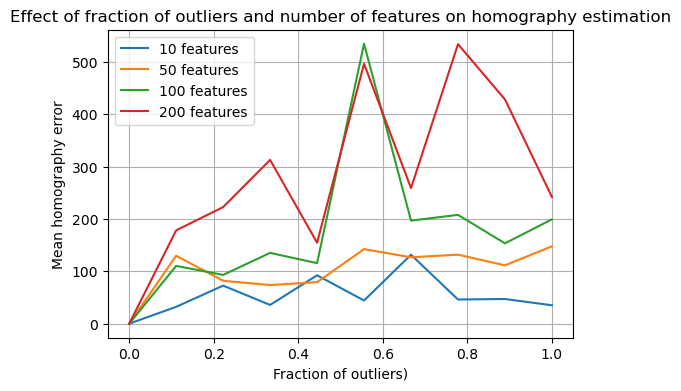

In [ ]:
fraction_outliers_range = np.linspace(0, 1, 10)  # from no outliers to 100% outliers
num_features = [10, 50, 100, 200]
repeats = 500
focal=1000

all_errors = {}

for num in num_features:
    mean_errors = []
    for noutliers_fraction in fraction_outliers_range:
        errors = []
        for _ in range(repeats):   # to get some average result since it changes every time
            # Generate synthetic points
            pts1, pts2, H_true = generate_2d_points(      # assumes that we have the camera matrix
                num=num,
                noutliers= round(num * noutliers_fraction),   # round to nearest integer
                noise=0.5,
                vergence=10.0,
                focal=focal
            )
            
            # estimated homography
            H_est = find_homography(pts1, pts2)
            err = homography_error(H_est, H_true, focal=focal)
            errors.append(err)
            
        mean_errors.append(np.mean(errors))
    
    all_errors[num] = mean_errors


plt.figure(figsize=(6, 4))
for num, errors in all_errors.items():
    plt.plot(fraction_outliers_range, errors, label=f'{num} features')

plt.xlabel("Fraction of outliers")
plt.ylabel("Mean homography error")
plt.title("Effect of fraction of outliers and number of features on homography estimation")
plt.grid(True)
plt.legend()
plt.show()

With more features, the homography becomes more sensitive to outliers, especially at a higher degree of noise.

The algorithm is much more robust to noise than to outliers. This makes sense because in find homography() we find H based on all the points, including the outliers!

To minimize the risk of introducing an outlier in the computations, one might use as few features as possible, instead of the full set of features.

In [141]:
print(pts1.shape)

print(pts1[0].shape)

print(pts2.shape)
print(len(pts1[1]))

idxs = np.arange(0, len(pts1[1])-1, 1)
random_idxs = np.random.choice(idxs, size=4)

print(random_idxs)

pts1_sel = (np.array([pts1[0, i] for i in random_idxs]), np.array([pts1[1, i] for i in random_idxs]))
pts2_sel = np.array([pts2[1, i] for i in random_idxs])

print(pts1_sel)
print(pts2_sel)

(2, 200)
(200,)
(2, 200)
200
[123  56 193 182]
(array([-104.35493308,  -25.4605796 ,  110.05189782,  151.21817183]), array([-54.96422213,   4.84553037,   9.5367749 ,  11.05548418]))
[-13.44303734  69.80692432  66.50675572  97.79090127]


### Task 2

In [227]:
img1 = cv2.imread('../Lab3/images/img1.jpg', flags=0)
img2 = cv2.imread('../Lab3/images/img2.jpg', flags=0)

In [291]:
def find_homography_RANSAC(pts1, pts2, niter = 100, thresh = 1.0):
    
    N = pts1.shape[1]  # needs to be at least 4 matches
    
    Hbest = None
    best_ninliers = -1
    best_inlier_idxs = None

    for _ in range(niter):
        # minimal required sample: 4, without duplicates
        sample_idxs = np.random.choice(N, size=4, replace=False)    # randomly sample 4 match indices (same in both images)
        pts1_sel = pts1[:, sample_idxs]
        pts2_sel = pts2[:, sample_idxs]     
 
        H = find_homography(pts1_sel, pts2_sel)
        
        # evaluate H against the full dataset (i.e. count the number of inliers among all features using homography H)
        ninliers, errors = count_homography_inliers(
            H=H, pts1=pts1, pts2=pts2, thresh=thresh
        )
        
        if ninliers > best_ninliers:
            best_ninliers = ninliers
            Hbest = H

    return Hbest, best_ninliers, errors

In [229]:
# pts1, pts2, _ = generate_2d_points(num=100, noutliers=0, noise = 0.5, vergence = 10.0, focal = 1200)
pts1, pts2 = extract_and_match_SIFT(img1, img2, num=100)
Hbest, best_ninliers, errors = find_homography_RANSAC(pts1, pts2, niter = 100, thresh = 1.0)

print(Hbest)
print(best_ninliers)

[[ 5.52860363e-03  1.95984425e-03 -2.44609881e-01]
 [-1.16714629e-03  5.90445132e-03  9.69564734e-01]
 [ 1.22183356e-06 -8.31372471e-08  6.29302843e-03]]
63


With the list of errors in errors, it is possible to identify the outliers and recompute a better estimate of the homography by calling find homography() with all features, but with the outliers excluded.

In [230]:
thresh = 1.0
print(len(errors))
print(pts1.shape)
mask = errors <= thresh   # mask for excluding outliers (keeping only inliers)
cleaned_pts1 = pts1[:, mask]
print(cleaned_pts1.shape)

cleaned_pts2 = pts2[:, mask]
print(cleaned_pts2.shape)

100
(2, 100)
(2, 47)
(2, 47)


In [231]:
H_new = find_homography(cleaned_pts1, cleaned_pts2)

In [232]:
print(H_new)

[[-5.50808094e-03 -1.95680068e-03  2.39996518e-01]
 [ 1.17752642e-03 -5.89525117e-03 -9.70717083e-01]
 [-1.17955906e-06  1.02513320e-07 -6.30140757e-03]]


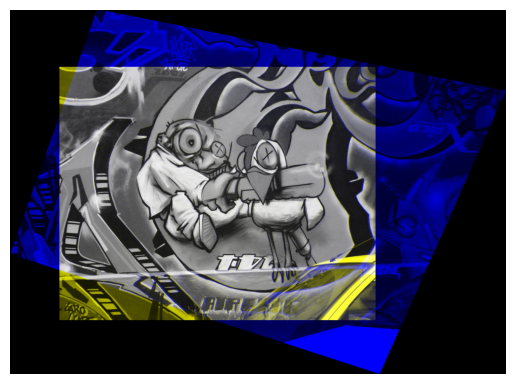

In [233]:
draw_homography(img1, img2, H_new)

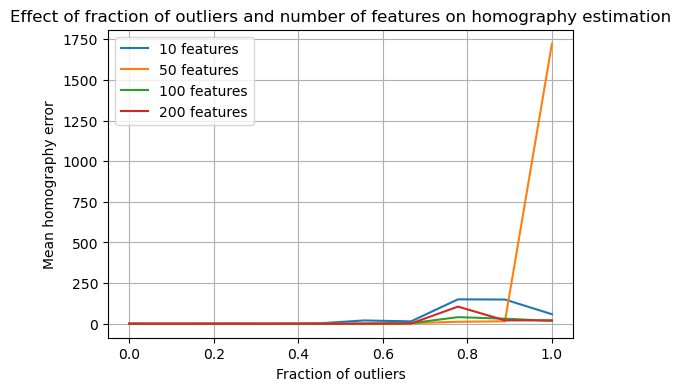

In [239]:
fraction_outliers_range = np.linspace(0, 1, 10)  # from no outliers to 100% outliers
num_features = [10, 50, 100, 200]
repeats = 10
focal=1000

all_errors = {}

for num in num_features:
    mean_errors = []
    for noutliers_fraction in fraction_outliers_range:
        errors = []
        for _ in range(repeats):   # to get some average result since it changes every time
            # Generate synthetic points
            pts1, pts2, H_true = generate_2d_points(      # assumes that we have the camera matrix
                num=num,
                noutliers= round(num * noutliers_fraction),   # round to nearest integer
                noise=0.5,
                vergence=10.0,
                focal=focal
            )
            
            # estimated homography
            H_est, ninliers, _ = find_homography_RANSAC(pts1, pts2, niter = 100, thresh = 1.0)
            err = homography_error(H_est, H_true, focal=focal)
            errors.append(err)
            
        mean_errors.append(np.mean(errors))
    
    all_errors[num] = mean_errors


plt.figure(figsize=(6, 4))
for num, errors in all_errors.items():
    plt.plot(fraction_outliers_range, errors, label=f'{num} features')

plt.xlabel("Fraction of outliers")
plt.ylabel("Mean homography error")
plt.title("Effect of fraction of outliers and number of features on homography estimation")
plt.grid(True)
plt.legend()
plt.show()

We see that RANSAC is more robust to outliers, because it minimizes the impact of these by maximizing amount of inliers influencing the estimation, while excluding outliers.

/var/folders/f3/_b5j26v125bc79rcfdhqwqwh0000gn/T/ipykernel_86124/2492258484.py:54: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


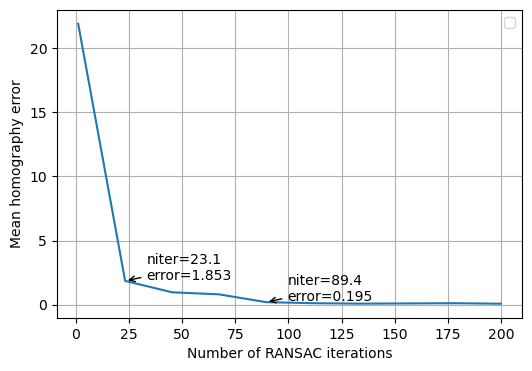

In [262]:
noutliers = 50  
num_features = 100
repeats = 20
focal=1000
niters = np.linspace(1, 200, 10)

mean_errors = []
for niter in niters:
    errors = []
    for _ in range(repeats):   # to get some average result since it changes every time
        # Generate synthetic points
        pts1, pts2, H_true = generate_2d_points(      # assumes that we have the camera matrix
            num=num_features,
            noutliers= noutliers,  
            noise=0.5,
            vergence=10.0,
            focal=focal
        )
        
        # estimated homography
        H_est, ninliers, _ = find_homography_RANSAC(pts1, pts2, niter = round(niter), thresh = 1.0)
        err = homography_error(H_est, H_true, focal=focal)
        errors.append(err)
            
    mean_errors.append(np.mean(errors))

target_x = 20
idx = (np.abs(niters - target_x)).argmin()
x_val = niters[idx]
y_val = mean_errors[idx]

target_x_2 = 80
idx_2 = (np.abs(niters - target_x_2)).argmin()
x_val_2 = niters[idx_2]
y_val_2 = mean_errors[idx_2]

plt.figure(figsize=(6, 4))
plt.plot(niters, mean_errors)
plt.xlabel("Number of RANSAC iterations")
plt.ylabel("Mean homography error")
plt.annotate(
    f"niter={x_val:.1f}\nerror={y_val:.3f}",
    xy=(x_val, y_val),
    xytext=(x_val + 10, y_val + 0.1),
    arrowprops=dict(arrowstyle="->")
)
plt.annotate(
    f"niter={x_val_2:.1f}\nerror={y_val_2:.3f}",
    xy=(x_val_2, y_val_2),
    xytext=(x_val_2 + 10, y_val_2 + 0.1),
    arrowprops=dict(arrowstyle="->")
)
plt.grid(True)
plt.legend()
plt.show()

About 75 iterations is enough to get a lower enough error than 1.0, where we after around 90 iterations can be sure to get a really low error.
It comes down to how long we are willing to run the algorithm for to get a low error.

/var/folders/f3/_b5j26v125bc79rcfdhqwqwh0000gn/T/ipykernel_86124/3468024705.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


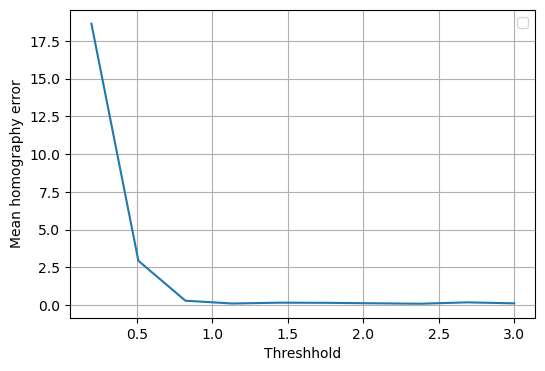

In [266]:
noutliers = 50  
num_features = 100
repeats = 20
focal=1000
niter = 75
threshholds = np.linspace(0.2, 3, 10)

mean_errors = []
for thresh in threshholds:
    errors = []
    for _ in range(repeats):   # to get some average result since it changes every time
        # Generate synthetic points
        pts1, pts2, H_true = generate_2d_points(      # assumes that we have the camera matrix
            num=num_features,
            noutliers= noutliers,  
            noise=0.5,
            vergence=10.0,
            focal=focal
        )
        
        # estimated homography
        H_est, ninliers, _ = find_homography_RANSAC(pts1, pts2, niter = niter, thresh = thresh)
        err = homography_error(H_est, H_true, focal=focal)
        errors.append(err)
            
    mean_errors.append(np.mean(errors))


plt.figure(figsize=(6, 4))
plt.plot(threshholds, mean_errors)
plt.xlabel("Threshhold")
plt.ylabel("Mean homography error")
plt.grid(True)
plt.legend()
plt.show()

(2, 100)
(2, 28)
(2, 28)


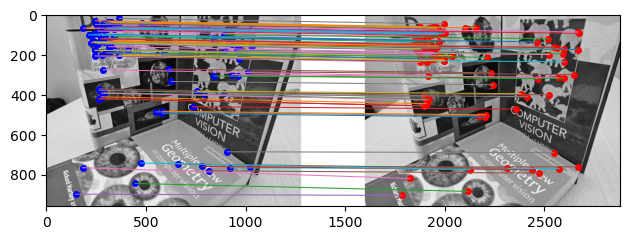

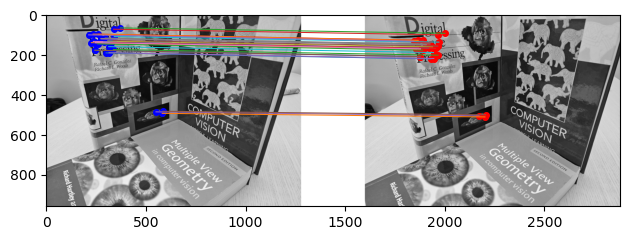

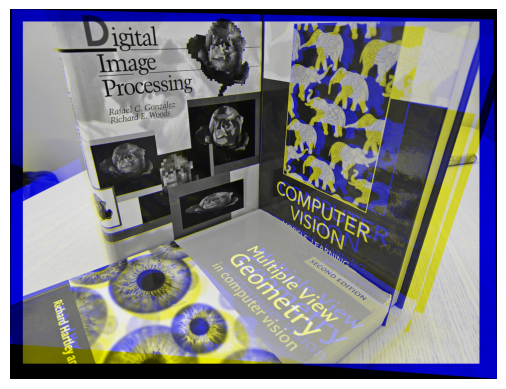

In [313]:
img1 = cv2.imread('../Lab3/images/books1.jpg', flags=0)
img2 = cv2.imread('../Lab3/images/books2.jpg', flags=0)
thresh = 1

pts1, pts2 = extract_and_match_SIFT(img1, img2, num=100)
Hbest, best_ninliers, errors = find_homography_RANSAC(pts1, pts2, niter = 100, thresh = thresh)

print(pts1.shape)
mask = errors <= thresh   # mask for excluding outliers (keeping only inliers)
cleaned_pts1 = pts1[:, mask]
print(cleaned_pts1.shape)

cleaned_pts2 = pts2[:, mask]
print(cleaned_pts2.shape)

draw_matches(pts1, pts2, img1 = img1, img2 = img2)

draw_matches(cleaned_pts1, cleaned_pts2, img1 = img1, img2 = img2)

Hbest, best_ninliers, errors = find_homography_RANSAC(cleaned_pts1, cleaned_pts2, niter = 10000, thresh = thresh)

draw_homography(img1, img2, Hbest, save = False)

Since images books1.jpg and books2.jpg have multiple objects with plane surfaces (not particularly dominated by one large flat surface), our homography is not perfect, because a single 3×3 homography can only model one plane. RANSAC tries to find some consensus, but since we only might have a few inliers, objects that are not on the "dominant" plane looks slightly distorted.

The Digital Image Processing book seem to be on the dominant plane in this case.

This is because the world is not flat, so we can no longer use a homography to relate matching image points between the two images.

## Recovering fundamental matrices

Develop a method for estimating a fundamental matrix with image features from two cameras covering the same scene from two different
orientations.

Use randomly generated points during the development

When deriving fundamental matrix estimation, we generate 3D points in a volume (e.g., a cube) rather than on a plane because the fundamental matrix is defined for general 3D scenes, and plane-only data would be wrong for estimating it. (In contrast, homography estimation must use planar points, because homographies describe the mapping between views of a plane). It is because the world is not assumed flat anymore.

In [320]:
#In this case, we do not have a planar assumption but generate 3D points in a cube located in front of both cameras
#  If you set the parameter spherical = True, the points will be generated on a 3D sphere, 
# which ensures that points are well spread and easier to visualize, which can be seen if you call draw_matches()
pts1, pts2, F = generate_3d_points(num=100, noutliers=0, noise = 0.5, vergence = 10.0, focal = 1000, spherical = False)

print(pts1.shape)

(2, 100)


In [347]:
def find_fmatrix(pts1, pts2, normalize = False):
    '''Estimate the F matrix from the matching points pts1 and pts2

        :param np.ndarray pts1: a 2xN_points array containing the coordinates of keypoints in the first image.
        :param np.ndarray pts2: a 2xN_points array conatining the coordinates of keypoints in the second image. 
            Matching points from pts1 and pts2 are found at corresponding indexes. 
        :param bool normalize: if True, points are normalized to improve stability.
        :returns np.ndarray: a 3x3 array representing the F matrix.

    '''
    # This function should support an arbitrary number of matching points, with a minimum of 8 (instead of 4)
    # Unlike the earlier case of homographies, the linear system of equations can too easily become ill-conditioned, 
    # if the selected features are not properly spread in image space (small errors in the input produce large errors in the solution)
    # If the points are all close together or have very large coordinates, the rows of B become almost linearly dependent.
    # then we get degenerate configurations (like all points lying on a line).
    
    # A common approach to overcome this is to first normalize the points by centering them around the origin with unit variance
    # then estimate the fundamental matrix, and finally adjust the matrix to reverse the normalization.
    
    # For better stability, normalize points to be centered at (0,0) with unit variance 
    if normalize:
        mean1 = np.mean(pts1, axis=1)
        std1 = np.std(pts1, axis=1)
        T1 = np.array([[1/std1[0], 0, -mean1[0]/std1[0]], [0, 1/std1[1], -mean1[1]/std1[1]], [0, 0, 1]])
        # homogenous coordinates
        pts1 = T1 @ np.vstack((pts1, np.ones((1, np.size(pts1, 1)))))
        mean2 = np.mean(pts2, axis=1)
        std2 = np.std(pts2, axis=1)
        # Translate points so their centroid is at the origin, and scale so that average distance from origin is sqrt(2)
        T2 = np.array([[1/std2[0], 0, -mean2[0]/std2[0]], [0, 1/std2[1], -mean2[1]/std2[1]], [0, 0, 1]])
        pts2 = T2 @ np.vstack((pts2, np.ones((1, np.size(pts2, 1)))))
        
    else:
        # just convert to homogeneous
        pts1 = np.vstack((pts1, np.ones((1, pts1.shape[1]))))
        pts2 = np.vstack((pts2, np.ones((1, pts2.shape[1]))))
    
    # print("pts1 shape", pts1.shape)    
    
    N = pts1.shape[1]     # shape is (2, N)
    # B = []
    B = np.zeros((N, 9))    # shape: N x 9, each correspondence gives one row

    for i in range(N):
        xa, ya, wa = pts1[:, i]
        xb, yb, wb = pts2[:, i]    # x', y' in the other image
        # divide by homogeneous coordinate to get inhomogeneous x/w, y/w
        B[i] = [
            (xb/wb)*(xa/wa), (xb/wb)*(ya/wa), xb/wb,
            (yb/wb)*(xa/wa), (yb/wb)*(ya/wa), yb/wb,
            xa/wa, ya/wa, 1]
        

    C = np.transpose(B) @ B     # square matrix
    U, S, Vh = np.linalg.svd(B)
    f = Vh[8,:]   # the eigenvector corresponding to the eigenvalue of C closest to zero
    
    F = f.reshape(3, 3)

    # Undo the normalization to get F in the original coordinates
    if normalize:
        F = T2.T @ F @ T1
    return F

In [348]:
pts1, pts2, F = generate_3d_points(num=100, noutliers=0, noise = 0.5, vergence = 10.0, focal = 1000, spherical = False)
F = find_fmatrix(pts1, pts2, normalize=True)

print(F)

[[ 2.69620273e-08  6.11418548e-07 -6.84547310e-05]
 [ 6.26259511e-07 -1.77436421e-08  7.07422191e-03]
 [ 7.17903020e-05 -7.07661456e-03 -5.48782338e-04]]


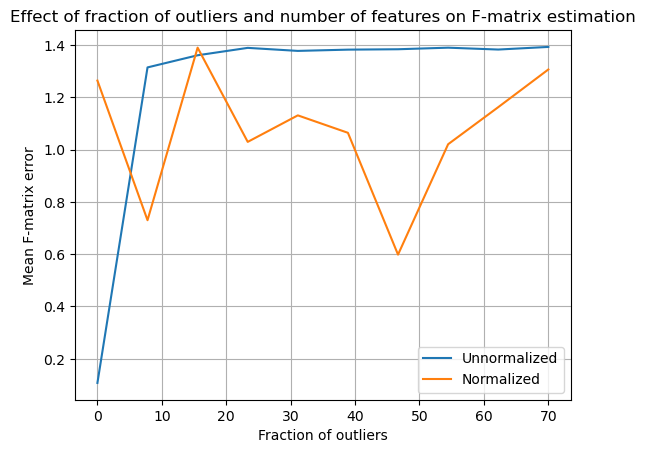

In [362]:
outliers_range = np.linspace(0, 70, 10)  # from no outliers to 100% outliers
num_features = 100
repeats = 10
focal=1000

mean_errors_not_norm = []
mean_errors_norm = []
for noutliers in outliers_range:
    errors_not_norm = []
    errors_norm = []
    for _ in range(repeats):   # to get some average result since it changes every time
        # Generate synthetic points
        pts1, pts2, F_true = generate_3d_points(
            num=num_features, 
            noutliers= round(noutliers), 
            noise = 0.5, 
            vergence = 10.0, 
            focal = 1000, 
            spherical = False
            )
        
        # estimated homography
        F_est_not_norm = find_fmatrix(pts1, pts2, normalize = False)
        err_not_norm = fmatrix_error(F_est_not_norm, F_true, focal=focal)
        errors_not_norm.append(err_not_norm)
        
        F_est_norm = find_fmatrix(pts1, pts2, normalize = True)
        err_norm = fmatrix_error(F_est_norm, F_true, focal=focal)
        errors_norm.append(err_norm)
        
    mean_errors_not_norm.append(np.mean(errors_not_norm))
    mean_errors_norm.append(np.mean(errors_norm))


plt.plot(outliers_range, mean_errors_not_norm, label='Unnormalized')
plt.plot(outliers_range, errors_norm, label='Normalized')

plt.xlabel("Fraction of outliers")
plt.ylabel("Mean F-matrix error")
plt.title("Effect of fraction of outliers and number of features on F-matrix estimation")
plt.grid(True)
plt.legend()
plt.show()

With unnormalized feature points, we quickly get a degrade in result if we start introducing outliers (even a small amount).
But with normalized feature points, we change their distribution so that less points are outliers, since we get a more even spread.